In [1]:
!pip install --upgrade --force-reinstall numpy pandas mendeleev pymatgen -q


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
langchain-core 0.3.55 requires packaging<25,>=23.2, but you have packaging 25.0 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == "Linux" and platform_machine

**:IMPORTING REQIURED MODULES**

In [2]:
!pip install CBFV -q

In [3]:
import pandas as pd
import numpy as np
from pymatgen.core import Composition, Element
from mendeleev import element
from CBFV.composition import generate_features

***READING THE DATASET WITH HELP OF PANDAS MODULE***

In [4]:
import os; df = pd.read_excel('../data/perovskites.xlsx' if os.path.exists('../data/perovskites.xlsx') else ('data/perovskites.xlsx' if os.path.exists('data/perovskites.xlsx') else 'https://raw.githubusercontent.com/Adhavan1801/PerovskiteML/main/data/perovskites.xlsx'))

In [5]:
df

,formula,target
0,ReBTeGeO6,380.39
1,GeZnAl2O6,372.33
2,TcCaMnBeO6,359.72
3,ReSeAlCeO6,355.14
4,OsSeAlCeO6,352.48
...,...,...
583,Au2SeTeBr6,24.82
584,HgOsTeAgBr6,24.24
585,HgIrTeAgBr6,24.20
586,HgPtTeAgBr6,24.13


**GENERATING FEATURES WITH CBFV(Magpie)**

In [6]:
X, y, formulas, skipped = generate_features(
    df,
    elem_prop='magpie',  # Choose a featurization scheme (e.g., 'oliynyk', 'magpie')
    drop_duplicates=True,  # Keep duplicates if any
    extend_features=True,  # Extend features or not
    sum_feat=True
   )

/usr/local/lib/python3.11/dist-packages/CBFV/composition.py:217: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if df['formula'].value_counts()[0] > 1:


Duplicate formula(e) removed using default pandas function


Processing Input Data: 100%|██████████| 587/587 [00:00<00:00, 13946.01it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 587/587 [00:00<00:00, 6933.05it/s]


	Creating Pandas Objects...


In [7]:
X

,sum_Number,sum_MendeleevNumber,sum_AtomicWeight,sum_MeltingT,sum_Column,sum_Row,sum_CovalentRadius,sum_Electronegativity,sum_NsValence,sum_NpValence,...,mode_NValence,mode_NsUnfilled,mode_NpUnfilled,mode_NdUnfilled,mode_NfUnfilled,mode_NUnfilled,mode_GSvolume_pa,mode_GSbandgap,mode_GSmagmom,mode_SpaceGroupNumber
0,212.0,817.0,493.254400,8069.86,146.0,29.0,889.0,28.69,20.0,31.0,...,6.0,0.0,2.0,0.0,0.0,2.0,9.105,0.000,0.0,12.0
1,136.0,816.0,287.979477,4099.82,148.0,26.0,880.0,27.52,20.0,28.0,...,6.0,0.0,2.0,0.0,0.0,2.0,9.105,0.000,0.0,12.0
2,140.0,701.0,298.024627,6952.80,114.0,27.0,954.0,26.66,20.0,24.0,...,6.0,0.0,2.0,0.0,0.0,2.0,9.105,0.000,0.0,12.0
3,228.0,753.0,528.260939,6286.27,135.0,31.0,992.0,27.82,20.0,29.0,...,6.0,0.0,2.0,0.0,0.0,2.0,9.105,0.000,0.0,12.0
4,229.0,756.0,532.283939,6133.27,136.0,31.0,985.0,28.12,20.0,29.0,...,6.0,0.0,2.0,0.0,0.0,2.0,9.105,0.000,0.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582,454.0,881.0,1079.917138,5486.12,156.0,45.0,1250.0,27.49,18.0,38.0,...,17.0,0.0,1.0,0.0,0.0,1.0,29.480,1.457,0.0,64.0
583,465.0,853.0,1105.712200,7092.71,149.0,46.0,1279.0,25.99,19.0,34.0,...,17.0,0.0,1.0,0.0,0.0,1.0,29.480,1.457,0.0,64.0
584,466.0,856.0,1107.699200,6525.71,150.0,46.0,1276.0,25.99,19.0,34.0,...,17.0,0.0,1.0,0.0,0.0,1.0,29.480,1.457,0.0,64.0
585,467.0,859.0,1110.566200,5828.11,151.0,46.0,1271.0,26.07,18.0,34.0,...,17.0,0.0,1.0,0.0,0.0,1.0,29.480,1.457,0.0,64.0


In [8]:
y

,target
0,380.39
1,372.33
2,359.72
3,355.14
4,352.48
...,...
582,24.82
583,24.24
584,24.20
585,24.13


In [9]:
formulas

,formula
0,ReBTeGeO6
1,GeZnAl2O6
2,TcCaMnBeO6
3,ReSeAlCeO6
4,OsSeAlCeO6
...,...
582,Au2SeTeBr6
583,HgOsTeAgBr6
584,HgIrTeAgBr6
585,HgPtTeAgBr6


**COUNTING THE FEATURES GIVEN BY CBFV(Magpie)**

In [10]:
count=0
for feature in X.columns:
    count+=1
print("Total number of features extracted :",count)

Total number of features extracted : 154


**FINDING THE COMPOSITION OF THE FORMULAS WITH HELP OF PYMATGEN**

In [11]:
comp = [formula for formula in df['formula']]

#**FINDING GEOMENTRIC FACTORS WHICH ARE NOT IN CBFV**

In [12]:
def featurize_pymatgen(formula):
  try:
        comp = Composition(formula)
        elements = list(comp.elements)
        k=str(comp)

        d=[]
        for i in k:
          if i.isdigit():
            d.append(i)


        # Mean properties
        mean_electronegativity = np.mean([el.X for el in elements if el.X is not None])
        mean_ionic_radii = np.mean([max(el.ionic_radii.values(), default=0) for el in elements])
        num_elements = len(elements)




        # Define A, B, and X site candidates
        x_site = next((el for el in elements if el.is_chalcogen or el.is_halogen), None)

        #print(b_elements)
        #print(x_site)
        #if elements[1]==elements[2] and num_elements==5:
        tolerance_factor, octahedral_factor, rho_A, rho_B = None, None, None, None
        if len(d)==4:

        # Case 1: A₂BB'X₆ (e.g., 2 A, 2 distinct B, 6 X)
          if  (d[0]=='2') and (d[1]=='1') and (d[2]=='1') :

              a_site = elements[0]
              b_site, b_prime_site = elements[1], elements[2]
              r_A = max(a_site.ionic_radii.values(), default=0)
              r_B = max(b_site.ionic_radii.values(), default=0)
              r_B_prime = max(b_prime_site.ionic_radii.values(), default=0)
              r_X = max(x_site.ionic_radii.values(), default=0)

              if r_A > 0 and r_B > 0 and r_B_prime > 0 and r_X > 0:
                  avg_r_B = (r_B + r_B_prime) / 2
                  tolerance_factor = (r_A + r_X) / (np.sqrt(2) * (avg_r_B + r_X))
                  octahedral_factor = avg_r_B / r_X
                  rho_A = (r_A - r_X) / (2 * r_X)
                  rho_B = (r_A - avg_r_B) / (2 * r_X)

        # Case 2: AA'B₂X₆ (e.g., 2 distinct A, 1 B type, 6 X)
          elif  (d[0]=='1') and (d[1]=='1') and (d[2]=='2'):

            a_site, a_prime_site = elements[0], elements[1]
            b_site = elements[2]
            r_A = max(a_site.ionic_radii.values(), default=0)

            r_A_prime = max(a_prime_site.ionic_radii.values(), default=0)

            r_B = max(b_site.ionic_radii.values(), default=0)
            r_X = max(x_site.ionic_radii.values(), default=0)

            if r_A > 0 and r_A_prime > 0 and r_B > 0 and r_X > 0:
                avg_r_A = (r_A + r_A_prime) / 2
                tolerance_factor = (avg_r_A + r_X) / (np.sqrt(2) * (r_B + r_X))
                octahedral_factor = r_B / r_X
                rho_A = (avg_r_A - r_X) / (2 * r_X)
                rho_B = (avg_r_A - r_B) / (2 * r_X)
        #AA'bbx6
        elif len(d)==3:
             a_site, a_prime_site = elements[0], elements[1]
             b_site = elements[2]
             r_A = max(a_site.ionic_radii.values(), default=0)

             r_A_prime = max(a_prime_site.ionic_radii.values(), default=0)

             r_B = max(b_site.ionic_radii.values(), default=0)
             r_X = max(x_site.ionic_radii.values(), default=0)

             if r_A > 0 and r_A_prime > 0 and r_B > 0 and r_X > 0:
                avg_r_A = (r_A + r_A_prime) / 2
                tolerance_factor = (avg_r_A + r_X) / (np.sqrt(2) * (r_B + r_X))
                octahedral_factor = r_B / r_X
                rho_A = (avg_r_A - r_X) / (2 * r_X)
                rho_B = (avg_r_A - r_B) / (2 * r_X)
        # Case 3: AA'BB'X₆ (e.g., 2 distinct A, 2 distinct B, 6 X)
        else:

            a_site, a_prime_site = elements[0], elements[1]
            b_site, b_prime_site = elements[2], elements[3]
            r_A = max(a_site.ionic_radii.values(), default=0)
            r_A_prime = max(a_prime_site.ionic_radii.values(), default=0)
            r_B = max(b_site.ionic_radii.values(), default=0)
            r_B_prime = max(b_prime_site.ionic_radii.values(), default=0)
            r_X = max(x_site.ionic_radii.values(), default=0)

            if r_A > 0 and r_A_prime > 0 and r_B > 0 and r_B_prime > 0 and r_X > 0:
                avg_r_A = (r_A + r_A_prime) / 2
                avg_r_B = (r_B + r_B_prime) / 2
                tolerance_factor = (avg_r_A + r_X) / (np.sqrt(2) * (avg_r_B + r_X))
                octahedral_factor = avg_r_B / r_X
                rho_A = (avg_r_A - r_X) / (2 * r_X)
                rho_B = (avg_r_A - avg_r_B) / (2 * r_X)

        # Return results
        return {

            "mean_electronegativity": mean_electronegativity,
            "mean_ionic_radii": mean_ionic_radii,
            "num_elements": num_elements,
            "tolerance_factor": tolerance_factor,
            "octahedral_factor": octahedral_factor,
            "mismatch_factor_A": rho_A,
            "mismatch_factor_B": rho_B
        }

  except Exception as e:
        print(f"Error featurizing {formula}: {e}")
        return {

            "mean_electronegativity": None,
            "mean_ionic_radii": None,
            "num_elements": None,
            "tolerance_factor": None,
            "octahedral_factor": None,
            "mismatch_factor_A": None,
            "mismatch_factor_B": None
        }

In [13]:

mean_electronegativity=[]
mean_ionic_radii=[]
tolerance_factor_d=[]
octahedral_factor=[]
mismatch_factor_A=[]
mismatch_factor_B=[]

for i in range(len(formulas)):
  features=featurize_pymatgen(formulas[i])

  mean_electronegativity.append(features['mean_electronegativity'])
  mean_ionic_radii.append(features['mean_ionic_radii'])
  tolerance_factor_d.append(features['tolerance_factor'])
  octahedral_factor.append(features['octahedral_factor'])
  mismatch_factor_A.append(features['mismatch_factor_A'])
  mismatch_factor_B.append(features['mismatch_factor_B'])

In [14]:
extra_features=pd.DataFrame( {

            "mean_electronegativity": mean_electronegativity,
            "mean_ionic_radii": mean_ionic_radii,
            "tolerance_factor": tolerance_factor_d,
            "octahedral_factor": octahedral_factor,
            "mismatch_factor_A": mismatch_factor_A,
            "mismatch_factor_B": mismatch_factor_B
        })

In [15]:
extra_features

,mean_electronegativity,mean_ionic_radii,tolerance_factor,octahedral_factor,mismatch_factor_A,mismatch_factor_B
0,2.2980,1.07600,0.531329,0.710145,-0.357488,-0.212560
1,2.1775,0.92125,0.780193,0.535714,-0.152778,0.079365
2,1.8920,0.94900,0.770365,0.619048,-0.118056,0.072421
3,2.1240,1.13900,0.807939,0.495924,-0.145380,0.106658
4,2.1840,1.13900,0.807939,0.495924,-0.145380,0.106658
...,...,...,...,...,...,...
582,2.5375,1.81000,0.624192,1.062500,-0.089674,-0.120924
583,2.2380,1.45600,0.588313,0.811594,-0.246377,-0.152174
584,2.2380,1.46600,0.593027,0.811594,-0.240338,-0.146135
585,2.2540,1.49000,0.604341,0.811594,-0.225845,-0.131643


In [16]:
x=pd.concat([X,extra_features],axis=1)

In [17]:
x

,sum_Number,sum_MendeleevNumber,sum_AtomicWeight,sum_MeltingT,sum_Column,sum_Row,sum_CovalentRadius,sum_Electronegativity,sum_NsValence,sum_NpValence,...,mode_GSvolume_pa,mode_GSbandgap,mode_GSmagmom,mode_SpaceGroupNumber,mean_electronegativity,mean_ionic_radii,tolerance_factor,octahedral_factor,mismatch_factor_A,mismatch_factor_B
0,212.0,817.0,493.254400,8069.86,146.0,29.0,889.0,28.69,20.0,31.0,...,9.105,0.000,0.0,12.0,2.2980,1.07600,0.531329,0.710145,-0.357488,-0.212560
1,136.0,816.0,287.979477,4099.82,148.0,26.0,880.0,27.52,20.0,28.0,...,9.105,0.000,0.0,12.0,2.1775,0.92125,0.780193,0.535714,-0.152778,0.079365
2,140.0,701.0,298.024627,6952.80,114.0,27.0,954.0,26.66,20.0,24.0,...,9.105,0.000,0.0,12.0,1.8920,0.94900,0.770365,0.619048,-0.118056,0.072421
3,228.0,753.0,528.260939,6286.27,135.0,31.0,992.0,27.82,20.0,29.0,...,9.105,0.000,0.0,12.0,2.1240,1.13900,0.807939,0.495924,-0.145380,0.106658
4,229.0,756.0,532.283939,6133.27,136.0,31.0,985.0,28.12,20.0,29.0,...,9.105,0.000,0.0,12.0,2.1840,1.13900,0.807939,0.495924,-0.145380,0.106658
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582,454.0,881.0,1079.917138,5486.12,156.0,45.0,1250.0,27.49,18.0,38.0,...,29.480,1.457,0.0,64.0,2.5375,1.81000,0.624192,1.062500,-0.089674,-0.120924
583,465.0,853.0,1105.712200,7092.71,149.0,46.0,1279.0,25.99,19.0,34.0,...,29.480,1.457,0.0,64.0,2.2380,1.45600,0.588313,0.811594,-0.246377,-0.152174
584,466.0,856.0,1107.699200,6525.71,150.0,46.0,1276.0,25.99,19.0,34.0,...,29.480,1.457,0.0,64.0,2.2380,1.46600,0.593027,0.811594,-0.240338,-0.146135
585,467.0,859.0,1110.566200,5828.11,151.0,46.0,1271.0,26.07,18.0,34.0,...,29.480,1.457,0.0,64.0,2.2540,1.49000,0.604341,0.811594,-0.225845,-0.131643


In [18]:
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

**SCALING THE DATASET**

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)
X_scaled = pd.DataFrame(X_scaled, columns=x.columns)

In [20]:

X_scaled

,sum_Number,sum_MendeleevNumber,sum_AtomicWeight,sum_MeltingT,sum_Column,sum_Row,sum_CovalentRadius,sum_Electronegativity,sum_NsValence,sum_NpValence,...,mode_GSvolume_pa,mode_GSbandgap,mode_GSmagmom,mode_SpaceGroupNumber,mean_electronegativity,mean_ionic_radii,tolerance_factor,octahedral_factor,mismatch_factor_A,mismatch_factor_B
0,-0.891991,0.029988,-0.817212,1.180740,0.273071,-1.188552,-1.369500,0.955219,0.73320,-0.625657,...,-1.078417,-1.089328,0.0,-1.110434,0.609314,-1.239155,-1.242525,-0.135586,-1.577830,-1.191914
1,-1.804079,0.008039,-1.830355,-1.438932,0.496476,-1.707144,-1.425929,0.269345,0.73320,-1.418305,...,-1.078417,-1.089328,0.0,-1.110434,-0.095076,-2.328964,1.664617,-1.779014,0.877998,1.606741
2,-1.756074,-2.516082,-1.780777,0.443636,-3.301406,-1.534280,-0.961959,-0.234801,0.73320,-2.475169,...,-1.078417,-1.089328,0.0,-1.110434,-1.763982,-2.133538,1.549814,-0.993875,1.294547,1.540166
3,-0.699972,-1.374740,-0.644435,0.003820,-0.955655,-0.842823,-0.723705,0.445210,0.73320,-1.154089,...,-1.078417,-1.089328,0.0,-1.110434,-0.407813,-0.795484,1.988733,-2.153906,0.966741,1.868392
4,-0.687971,-1.308893,-0.624580,-0.097139,-0.843953,-0.842823,-0.767594,0.621075,0.73320,-1.154089,...,-1.078417,-1.089328,0.0,-1.110434,-0.057080,-0.795484,1.988733,-2.153906,0.966741,1.868392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582,2.012290,1.434716,2.078289,-0.524168,1.390096,1.577275,0.893920,0.251759,-1.67794,1.223856,...,1.087454,0.361511,0.0,0.906999,2.009325,3.929957,-0.157732,3.184188,1.635030,-0.313406
583,2.144303,0.820148,2.205602,0.535957,0.608179,1.750139,1.075746,-0.627567,-0.47237,0.166992,...,1.087454,0.361511,0.0,0.906999,0.258580,1.436952,-0.576857,0.820236,-0.244873,-0.612996
584,2.156304,0.885994,2.215409,0.161817,0.719881,1.750139,1.056937,-0.627567,-0.47237,0.166992,...,1.087454,0.361511,0.0,0.906999,0.258580,1.507376,-0.521789,0.820236,-0.172430,-0.555104
585,2.168305,0.951841,2.229559,-0.298502,0.831584,1.750139,1.025587,-0.580669,-1.67794,0.166992,...,1.087454,0.361511,0.0,0.906999,0.352109,1.676393,-0.389627,0.820236,0.001434,-0.416164


**SPLITING THE DATASET FOR TRAIN AND TEST**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# **LGBM Regressor**

In [22]:
from lightgbm import LGBMRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# 1. Feature Selection with RFE
lgbm_for_rfe = LGBMRegressor(n_estimators=100, random_state=42)
rfe = RFE(estimator=lgbm_for_rfe, n_features_to_select=20)
rfe.fit(X_scaled, y)

# 2. Select features
selected_features = X_scaled.columns[rfe.support_]
X_rfe = X_scaled[selected_features]

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000706 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7734
[LightGBM] [Info] Number of data points in the train set: 587, number of used features: 146
[LightGBM] [Info] Start training from score 111.483458
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000145 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3549
[LightGBM] [Info] Number of data points in the train set: 587, number of used features: 27
[LightGBM] [Info] Start training from score 111.483458
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3161
[LightGBM] [Info] Number of data points in the train set: 587, number of used features: 25
[LightGBM] [Info] Start training from score 111.483458
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [23]:
# 4. Model Training
model = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

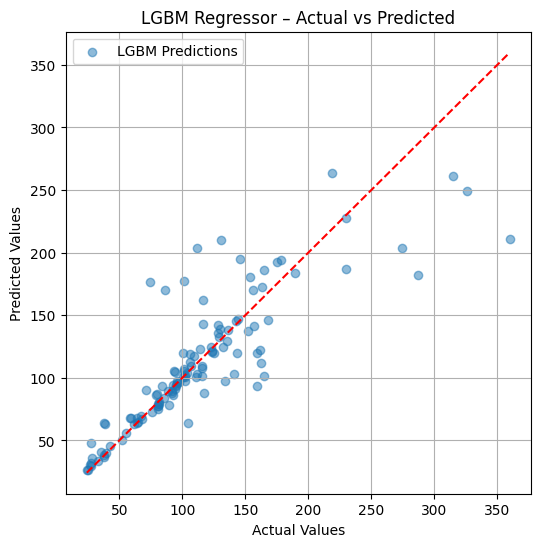

R2 Score: 0.721971330731779
Mean Absolute Error (MAE): 18.06254884006971
Mean Squared Error (MSE): 1031.453208206063


In [24]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# 5. Scatter Plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label="LGBM Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("LGBM Regressor – Actual vs Predicted")  # Updated title
plt.legend()
plt.grid(True)
plt.show()

# 6. Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)


#**After HyperTuning**

In [25]:
from sklearn.model_selection import GridSearchCV

# 4. Hyperparameter Grid
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70],
    'min_child_samples': [10, 20],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=LGBMRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("\nStarting grid search...")
grid_search.fit(X_train, y_train)

# 5. Use Best Model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)




Starting grid search...
Fitting 5 folds for each of 1458 candidates, totalling 7290 fits


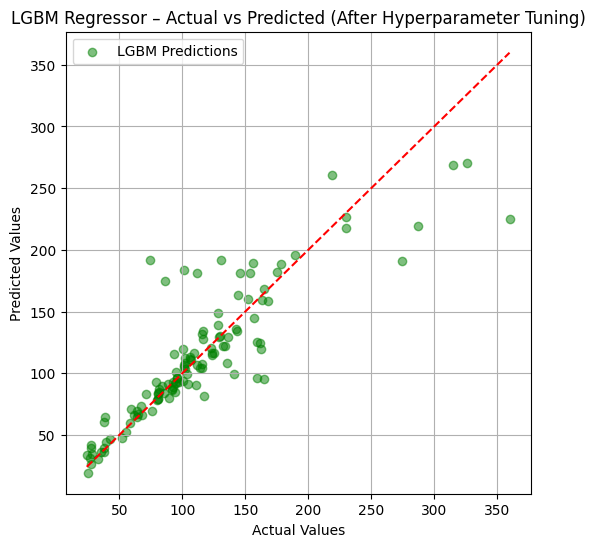

R2 Score: 0.7675760676215646
Mean Absolute Error (MAE): 16.781085819291963
Mean Squared Error (MSE): 862.2650726869056


In [26]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 6. Scatter Plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green', label="LGBM Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Reference line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("LGBM Regressor – Actual vs Predicted (After Hyperparameter Tuning)")  # Updated title
plt.legend()
plt.grid(True)
plt.show()



# Calculate metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Print metrics
print("R2 Score:", r2)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
